# LMM — Age estimation, Lower third molar

In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/nnnattttt/Knowledge_XAIeve/venv/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <3C299107-E46F-31BA-AFE1-EA0CB28E5C55> /Users/nnnattttt/Knowledge_XAIeve/venv/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [5]:
%%R
install.packages(c("dplyr", "ggplot2", "nlme", "car", "performance", "readr"),
                  repos = "https://cloud.r-project.org", quiet = TRUE)

also installing the dependencies ‘stringi’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘backports’, ‘purrr’, ‘stringr’, ‘tidyr’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘modelr’, ‘broom’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’



## 1. Load and prepare data

In [6]:
%%R
library(dplyr)
library(nlme)
library(performance)
library(car)
library(ggplot2)

data <- read.csv("data/age.csv")

# Factor encoding
data$patient_id          <- as.factor(data$patient_id)
data$Gender_predict_int  <- as.factor(data$Gender_predict_int)

# Filter: restrict to developmental age window and remove outliers
data <- subset(data, Age_predict_int >= 10 & Age_predict_int <= 25)
data <- subset(data, ratio_cr <= 5)

# Mean-centre crown-root ratio to reduce collinearity with quadratic term
data$ratio_cr_c <- data$ratio_cr - mean(data$ratio_cr)
cat("Observations :", nrow(data), "\n")
cat("Patients     :", n_distinct(data$patient_id), "\n")

Observations : 42490 
Patients     : 430 


Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

Need help getting started? Try the R Graphics Cookbook:
https://r-graphics.org


## 2. Patient-level correlation (Pearson)
Aggregate to patient level first to avoid pseudoreplication in correlation

In [7]:
%%R
data_agg <- data %>%
  group_by(patient_id) %>%
  summarise(
    mean_ratio_cr    = mean(ratio_cr),
    mean_age_predict = mean(Age_predict)
  )

cor.test(data_agg$mean_ratio_cr,
         data_agg$mean_age_predict,
         method = "pearson")


	Pearson's product-moment correlation

data:  data_agg$mean_ratio_cr and data_agg$mean_age_predict
t = -20.541, df = 428, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.7492271 -0.6535623
sample estimates:
       cor 
-0.7045817 



## 3. Fit Linear Mixed-Effects Model (LME via nlme) 

Fixed effects:  
   ratio_cr_c             — linear crown-root ratio (mean-centred)  
   I(ratio_cr_c^2)        — quadratic term (U-shaped developmental curve)  
   Gender_predict_int     — sex (0 = Female, 1 = Male)  
   ratio_cr_c:Gender_predict_int — interaction: sex modifies ratio effect  

 Random effect: random intercept per patient  
   accounts for repeated measures (multiple perturbation steps per patient)  

 Variance structure: varPower  
   allows residual variance to scale with crown-root ratio  

In [8]:
%%R
model <- lme(
  Age_predict ~ ratio_cr_c + I(ratio_cr_c^2) +
    Gender_predict_int +
    ratio_cr_c:Gender_predict_int,
  random  = ~ 1 | patient_id,
  weights = varPower(form = ~ ratio_cr_c),
  data    = data
)

summary(model)

Linear mixed-effects model fit by REML
  Data: data 
       AIC   BIC    logLik
  38533.74 38603 -19258.87

Random effects:
 Formula: ~1 | patient_id
        (Intercept)  Residual
StdDev:    3.676949 0.3255515

Variance function:
 Structure: Power of variance covariate
 Formula: ~ratio_cr_c 
 Parameter estimates:
     power 
-0.1024357 
Fixed effects:  Age_predict ~ ratio_cr_c + I(ratio_cr_c^2) + Gender_predict_int +      ratio_cr_c:Gender_predict_int 
                                   Value  Std.Error    DF  t-value p-value
(Intercept)                    16.756590 0.17754081 42056 94.38162       0
ratio_cr_c                     -0.092955 0.01074491 42056 -8.65106       0
I(ratio_cr_c^2)                 0.030713 0.00277226 42056 11.07862       0
Gender_predict_int1             0.079765 0.01264908 42056  6.30599       0
ratio_cr_c:Gender_predict_int1 -0.048267 0.00949524 42056 -5.08333       0
 Correlation: 
                               (Intr) rt_cr_ I(__^2 Gnd__1
ratio_cr_c         

## 4. Assumption checks

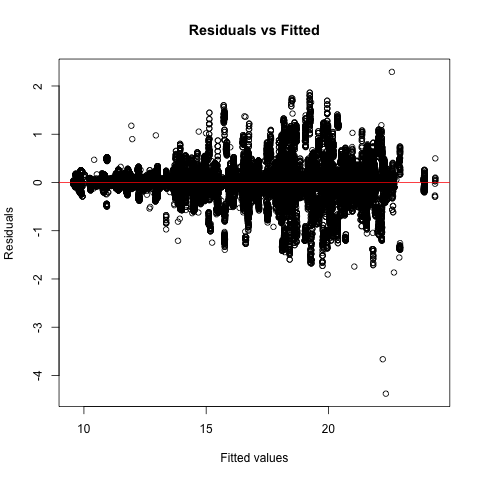

In [9]:
%%R
res <- resid(model)

# 4a. Residuals vs Fitted (Homoscedasticity)
plot(fitted(model), res,
     xlab = "Fitted values", ylab = "Residuals",
     main = "Residuals vs Fitted")
abline(h = 0, col = "red")

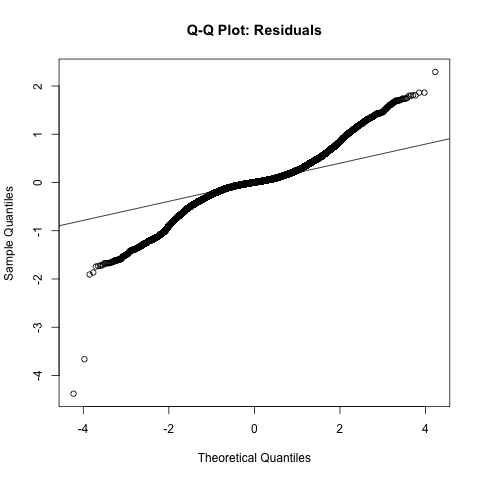

In [10]:
%%R
# 4b. Q-Q plot of residuals (Normality of residuals)
qqnorm(res, main = "Q-Q Plot: Residuals")
qqline(res)

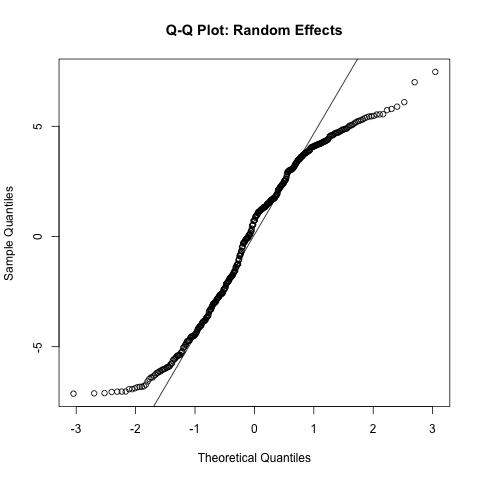

In [11]:
%%R
# 4c. Q-Q plot of random effects (Normality of random effects)
ranef_vals <- random.effects(model)$`(Intercept)`
qqnorm(ranef_vals, main = "Q-Q Plot: Random Effects")
qqline(ranef_vals)

In [12]:
%%R
# 4d. VIF (from equivalent fixed-effects model) — Multicollinearity
model_lm <- lm(
  Age_predict ~ ratio_cr_c + I(ratio_cr_c^2) +
    Gender_predict_int +
    ratio_cr_c:Gender_predict_int,
  data = data
)
vif(model_lm)

                   ratio_cr_c               I(ratio_cr_c^2) 
                     4.263181                      3.217213 
           Gender_predict_int ratio_cr_c:Gender_predict_int 
                     1.003430                      1.948233 


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif


## 5. Model fit: R-squared and ICC

In [13]:
%%R
r2(model)

# R2 for Mixed Models

  Conditional R2: 0.992
     Marginal R2: 0.000


Registered S3 method overwritten by 'lme4':
  method           from
  na.action.merMod car 


## 6. Predict over grid (fixed effects only, level = 0)

In [14]:
%%R
newdata <- expand.grid(
  ratio_cr_c         = seq(min(data$ratio_cr_c),
                            max(data$ratio_cr_c),
                            length.out = 500),
  Gender_predict_int = factor(c(0, 1))
)

newdata$ratio_cr    <- newdata$ratio_cr_c + mean(data$ratio_cr)
newdata$Age_predict <- predict(model, newdata, level = 0)
newdata$Sex         <- ifelse(newdata$Gender_predict_int == 0,
                               "Female (0)", "Male (1)")

# Minimum predicted age per sex
min_point <- newdata %>%
  group_by(Sex) %>%
  slice_min(Age_predict) %>%
  slice(1)

print(min_point)

# A tibble: 2 × 5
# Groups:   Sex [2]
  ratio_cr_c Gender_predict_int ratio_cr Age_predict Sex       
       <dbl> <fct>                 <dbl>       <dbl> <chr>     
1       1.51 0                      2.41        16.7 Female (0)
2       2.30 1                      3.21        16.7 Male (1)  


## 7. Plots

`geom_smooth()` using formula = 'y ~ x'


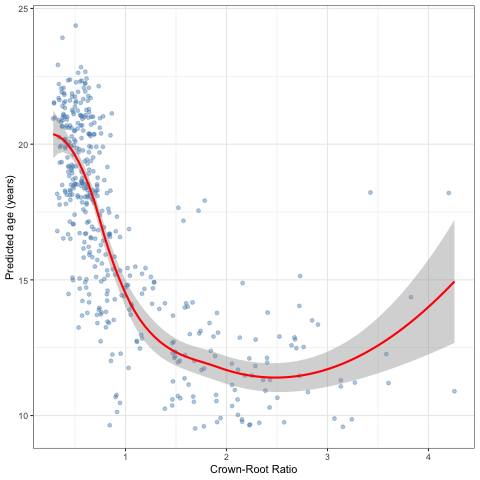

In [15]:
%%R
# 7a. Patient-level scatter with LOESS
ggplot(data_agg, aes(x = mean_ratio_cr, y = mean_age_predict)) +
  geom_point(alpha = 0.4, color = "steelblue") +
  geom_smooth(method = "loess", color = "red", se = TRUE) +
  labs(x = "Crown-Root Ratio",
       y = "Predicted age (years)") +
  theme_bw()

In addition: Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


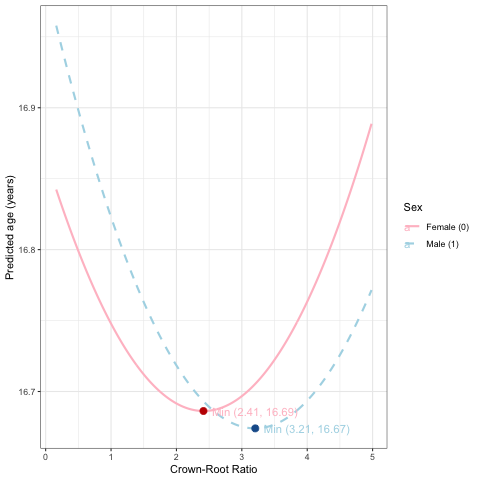

In [16]:
%%R
# 7b. LMM fixed-effects curve with minimum points
ggplot(newdata, aes(x = ratio_cr, y = Age_predict,
                    color = Sex, linetype = Sex)) +
  geom_line(size = 1) +
  geom_point(data = min_point,
             aes(x = ratio_cr, y = Age_predict),
             size = 3,
             color = c("#C20000", "#1A5C99")) +
  geom_text(data = min_point,
            aes(label = paste0("Min (", round(ratio_cr, 2),
                               ", ", round(Age_predict, 2), ")")),
            hjust = -0.1, size = 4) +
  scale_color_manual(values = c("Female (0)" = "pink",
                                 "Male (1)"   = "lightblue")) +
  scale_linetype_manual(values = c("Female (0)" = "solid",
                                    "Male (1)"   = "dashed")) +
  labs(x = "Crown-Root Ratio",
       y = "Predicted age (years)",
       color = "Sex", linetype = "Sex") +
  theme_bw()